# 矩阵分解与低秩近似

学习目标：用 QR 与 SVD 分解重构矩阵，解释奇异值、秩与截断误差，构造伪逆并比较低秩表示的误差和存储量。

前置知识：矩阵乘法与转置、基、秩、正交、特征值、Frobenius 范数。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；主线只处理有限维实矩阵，Cholesky 为选学。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 QR 分解把列向量写成正交方向的组合

考虑两个三维列向量 $a_1=(1,1,0)^T$、$a_2=(1,1,2)^T$。第二个向量可以拆成第一个方向上的部分与竖直方向上的部分：

$$a_1=\sqrt2q_1,\qquad a_2=\sqrt2q_1+2q_2,$$

其中 $q_1=(1,1,0)^T/\sqrt2$、$q_2=(0,0,1)^T$，长度均为 1，且内积为零。把两列合起来，就得到

$$A=\begin{pmatrix}1&1\\1&1\\0&2\end{pmatrix}
=\underbrace{\begin{pmatrix}1/\sqrt2&0\\1/\sqrt2&0\\0&1\end{pmatrix}}_Q
\underbrace{\begin{pmatrix}\sqrt2&\sqrt2\\0&2\end{pmatrix}}_R.$$

这就是一个 QR 分解：$Q$ 的列标准正交，$R$ 为上三角矩阵。先核对这个手算结果，再使用库函数。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11}
)

a = np.array([[1.0, 1.0], [1.0, 1.0], [0.0, 2.0]])
q_hand = np.array([[1 / np.sqrt(2), 0], [1 / np.sqrt(2), 0], [0, 1]])
r_hand = np.array([[np.sqrt(2), np.sqrt(2)], [0, 2]])

print("Q R：\n", q_hand @ r_hand)  # 预期为 [[1. 1.] [1. 1.] [0. 2.]]。
print("Q^T Q：\n", q_hand.T @ q_hand)  # 预期为 [[1. 0.] [0. 1.]]。
print("重构的 Frobenius 误差：", np.linalg.norm(a - q_hand @ r_hand, "fro"))  # 预期接近 0；本次计算为 0。
# 重构应接近 A，Q^T Q 应接近二阶单位矩阵。

Q R：
 [[1. 1.]
 [1. 1.]
 [0. 2.]]
Q^T Q：
 [[1. 0.]
 [0. 1.]]
重构的 Frobenius 误差： 0.0


### 1.1 上三角系数来自逐列去掉投影

对两个线性无关的列向量，Gram–Schmidt 过程先归一化第一列，再从第二列去掉已有方向上的投影：

$$q_1=\frac{a_1}{\|a_1\|_2},\qquad
w_2=a_2-(q_1^Ta_2)q_1,\qquad q_2=\frac{w_2}{\|w_2\|_2}.$$

这里 $w_2$ 是第二列剩余的正交分量；$\|\cdot\|_2$ 表示向量的欧氏长度。第一列只需要 $q_1$，第二列才需要 $q_1,q_2$，因此系数矩阵为上三角。由 $Q^TQ=I$，还可得到 $R=Q^TA$。

若第二列依赖第一列，$w_2=0$，不能再除以其长度。这里的小步骤用于理解 QR 的来源；实际计算直接使用 np.linalg.qr，不把这段两列演示当作完整的数值算法。

In [2]:
a1 = a[:, 0]
a2 = a[:, 1]
q1 = a1 / np.linalg.norm(a1)
w2 = a2 - (q1 @ a2) * q1
q2 = w2 / np.linalg.norm(w2)
q_from_columns = np.column_stack([q1, q2])

print("第二列剩余部分：", w2)  # 约为 (0, 0, 2)。
print("R = Q^T A：\n", q_from_columns.T @ a)  # 预期接近 [[√2, √2], [0, 2]]；本次左下角约为 2.2e-16。
print("两个方向的内积：", q1 @ q2)  # 接近零。

第二列剩余部分： [2.22044605e-16 2.22044605e-16 2.00000000e+00]
R = Q^T A：
 [[1.41421356e+00 1.41421356e+00]
 [2.22044605e-16 2.00000000e+00]]
两个方向的内积： 1.570092458683775e-16


### 1.2 完整形式与简化形式的形状

现在令 $A\in\mathbb R^{m\times n}$，$m,n$ 为正整数，$p=\min(m,n)$。NumPy 的两种 QR 输出形状如下；在矩形情形，“上三角”指主对角线下方为零的上梯形结构。

| mode | 中文名称／含义 | Q 的形状 | R 的形状 |
| --- | --- | --- | --- |
| reduced | 简化形式，默认值 | $m\times p$ | $p\times n$ |
| complete | 完整形式 | $m\times m$ | $m\times n$ |

两种形式都满足 $A=QR$。简化形式满足 $Q^TQ=I_p$，其中 $I_p$ 为 $p$ 阶单位矩阵；当 $m>p$ 时，$QQ^T$ 不等于 $I_m$。完整形式的 $Q$ 是方形正交矩阵。

检查分解时同时查看重构误差和正交误差。对 $E\in\mathbb R^{m\times n}$，$\|E\|_F=\sqrt{\sum_{i=1}^{m}\sum_{j=1}^{n}E_{ij}^2}$。下面的输入规模和元素都较小，误差小于 $10^{-12}$ 用作数值核对，不等于精确代数证明。

In [3]:
for mode in ["reduced", "complete"]:
    q, r = np.linalg.qr(a, mode=mode)
    print(mode, "形状：", q.shape, r.shape)  # reduced 的 Q/R 形状为 (3, 2)/(2, 2)；complete 为 (3, 3)/(3, 2)。
    print("  重构误差：", np.linalg.norm(a - q @ r, "fro"))  # 两种模式的重构误差都接近 0，本次约 6e-16。
    print("  列正交误差：", np.linalg.norm(q.T @ q - np.eye(q.shape[1]), "fro"))  # 预期两种模式的列正交误差接近 0；本次都小于 1e-14。
    # reduced 的差为 1；complete 的差接近 0，本次约 5.3e-16。
    print("  Q Q^T 与三阶单位阵的差：", np.linalg.norm(q @ q.T - np.eye(3), "fro"))
# reduced 的 Q 是 3×2，Q Q^T 不等于 I；complete 的 Q 是 3×3。

reduced 形状： (3, 2) (2, 2)
  重构误差： 5.978733960281817e-16
  列正交误差： 4.440892098500626e-16
  Q Q^T 与三阶单位阵的差： 1.0
complete 形状： (3, 3) (3, 2)
  重构误差： 5.978733960281817e-16
  列正交误差： 5.311371344176569e-16
  Q Q^T 与三阶单位阵的差： 5.311371344176569e-16


QR 结果可以有符号差异。把 $Q$ 的某一列乘 $-1$，同时把 $R$ 的对应行乘 $-1$，乘积保持不变，所以库结果不必逐项等于手算版本。

简化形式也不等于“自动删除相关列”。即使输入秩小于 $p$，返回的 Q、R 仍按上表定形；此时 Q 的全部列不能直接当作输入列空间的一组基。下面故意让第二列成为第一列的两倍。

In [4]:
dependent = np.array([[1.0, 2.0], [1.0, 2.0], [0.0, 0.0]])
q_dep, r_dep = np.linalg.qr(dependent, mode="reduced")
print("形状仍为：", q_dep.shape, r_dep.shape)  # 预期为 (3, 2) (2, 2)。
print("R：\n", r_dep)  # 第二行接近零，输入的列空间只有一个方向。
print("重构误差：", np.linalg.norm(dependent - q_dep @ r_dep, "fro"))  # 本次数值约为 1e-15。

形状仍为： (3, 2) (2, 2)
R：
 [[-1.41421356 -2.82842712]
 [ 0.          0.        ]]
重构误差： 1.047382306668854e-15


## 2 SVD 把矩阵拆成输入方向、伸缩与输出方向

矩形矩阵 $B=\begin{pmatrix}3&0\\0&1\\0&0\end{pmatrix}$ 把二维输入送到三维：沿第一个坐标方向伸长 3 倍，沿第二个方向伸长 1 倍。奇异值分解（singular value decomposition，SVD）把这种描述推广到任意实矩阵。

对于 $A\in\mathbb R^{m\times n}$，SVD 总是存在：

$$A=U\Sigma V^T.$$

完整形式中，$U$ 是 $m\times m$ 正交矩阵，$V$ 是 $n\times n$ 正交矩阵，$\Sigma$ 是 $m\times n$ 的矩形对角矩阵。其主对角线上有 $p=\min(m,n)$ 个非负数，按

$$\sigma_1\ge\sigma_2\ge\cdots\ge\sigma_p\ge0$$

排列，称为奇异值。$V^T$ 先改写输入坐标，$\Sigma$ 沿坐标方向伸缩并处理维度差异，$U$ 再给出输出坐标方向。SVD 不要求 A 为方阵，也不要求可逆或可对角化。

In [5]:
b = np.array([[3.0, 0.0], [0.0, 1.0], [0.0, 0.0]])
u, singular_values, vh = np.linalg.svd(b, full_matrices=False)
print("奇异值：", singular_values)  # 3、1。
print("U、奇异值数组、V^T 的形状：", u.shape, singular_values.shape, vh.shape)  # 预期为 (3, 2) (2,) (2, 2)。
print("重构：\n", (u * singular_values) @ vh)  # 预期为 [[3. 0.] [0. 1.] [0. 0.]]。
# 一维奇异值数组沿 U 的列广播缩放，等价于 U @ diag(singular_values)。

奇异值： [3. 1.]
U、奇异值数组、V^T 的形状： (3, 2) (2,) (2, 2)
重构：
 [[3. 0.]
 [0. 1.]
 [0. 0.]]


### 2.1 分清完整、简化与截断

np.linalg.svd 返回 U、一维奇异值数组以及 Vh。实数情形中 Vh 就是 $V^T$，不是 $V$；名字中的 h 表示接口也支持复数的共轭转置，本章不涉及复数计算。

| full_matrices | 中文名称／含义 | U 的形状 | 奇异值数组形状 | Vh 的形状 |
| --- | --- | --- | --- | --- |
| True | 完整形式，默认值 | $m\times m$ | $(p,)$ | $n\times n$ |
| False | 简化形式 | $m\times p$ | $(p,)$ | $p\times n$ |

简化 SVD 保留全部 $p$ 个奇异值，包括零值，不主动做低秩近似。简化形式满足 $U^TU=I_p$、$V^TV=I_p$；在代码中后一式应检查 vh @ vh.T。只保留前 $k<p$ 项的“截断”是另外的选择。

完整形式的 $\Sigma$ 应为 $m\times n$。当矩阵不是方阵时，直接把 np.diag 返回的 $p\times p$ 数组放进完整形式的乘法，会造成形状不匹配。

In [6]:
u_full, s_full, vh_full = np.linalg.svd(b, full_matrices=True)
# 完整形式需要与原矩阵同形的矩形 Σ，奇异值只放在前 p 个对角位置。
sigma_full = np.zeros(b.shape)
p = min(b.shape)
sigma_full[:p, :p] = np.diag(s_full)
print("完整形式形状：", u_full.shape, sigma_full.shape, vh_full.shape)  # 预期为 (3, 3) (3, 2) (2, 2)。
print("完整重构误差：", np.linalg.norm(b - u_full @ sigma_full @ vh_full, "fro"))  # 预期接近 0；本次计算为 0。
print("简化 U 列正交误差：", np.linalg.norm(u.T @ u - np.eye(p), "fro"))  # 预期接近 0；本次计算为 0。
print("简化 V 列正交误差：", np.linalg.norm(vh @ vh.T - np.eye(p), "fro"))  # 预期接近 0；本次计算为 0。

# 再转置成宽矩阵，观察简化分解的形状如何随输入改变。
u_wide, s_wide, vh_wide = np.linalg.svd(b.T, full_matrices=False)
print("宽矩阵的简化形状：", u_wide.shape, s_wide.shape, vh_wide.shape)  # 预期为 (2, 2) (2,) (2, 3)。
print("宽矩阵重构误差：", np.linalg.norm(b.T - (u_wide * s_wide) @ vh_wide, "fro"))  # 预期接近 0；本次计算为 0。

完整形式形状： (3, 3) (3, 2) (2, 2)
完整重构误差： 0.0
简化 U 列正交误差： 0.0
简化 V 列正交误差： 0.0
宽矩阵的简化形状： (2, 2) (2,) (2, 3)
宽矩阵重构误差： 0.0


### 2.2 奇异值与特征值的关系

设 $u_i$ 和 $v_i$ 分别为 U、V 的第 $i$ 列，则对 $1\le i\le p$ 有

$$Av_i=\sigma_i u_i.$$

这与 $Av_i=\lambda_i v_i$ 不同：输入与输出方向可以不同，甚至属于不同维度的空间。由完整 SVD 可推导

$$A^TA=V\Sigma^T\Sigma V^T.$$

因此 $A^TA$ 的非零特征值是非零奇异值的平方；维度多出的部分补零。下面用小矩阵核对这个数学关系，实际求 SVD 则直接调用 svd。

奇异值不能当作 A 的特征值：它们永远非负。对实对称矩阵，奇异值等于特征值的绝对值，负特征值的符号会消失。

In [7]:
print("B^T B：\n", b.T @ b)  # 预期为 [[9. 0.] [0. 1.]]。
print("B^T B 的递增特征值：", np.linalg.eigh(b.T @ b).eigenvalues)  # 预期为 [1. 9.]。
print("B 奇异值平方的递增排列：", np.sort(singular_values**2))  # 预期为 [1. 9.]。
print("B V - U Sigma 的误差：", np.linalg.norm(b @ vh.T - u * singular_values, "fro"))  # 预期接近 0；本次计算为 0。

signed = np.diag([-3.0, 1.0])
print("实对称矩阵的特征值：", np.linalg.eigh(signed).eigenvalues)  # 预期为 [-3. 1.]。
print("同一矩阵的奇异值：", np.linalg.svd(signed, compute_uv=False))  # 3、1。

B^T B：
 [[9. 0.]
 [0. 1.]]
B^T B 的递增特征值： [1. 9.]
B 奇异值平方的递增排列： [1. 9.]
B V - U Sigma 的误差： 0.0
实对称矩阵的特征值： [-3.  1.]
同一矩阵的奇异值： [3. 1.]


### 2.3 奇异向量可能不唯一

一对左右奇异向量同时变号，$\sigma_i u_i v_i^T$ 不变。重复奇异值还允许在对应子空间内同步换用不同的标准正交基；零奇异值对应方向的基也可能不同。

例如 $2I$ 可以写为 $I(2I)I^T$，也可以写为 $W(2I)W^T$，其中 W 是任意同阶正交矩阵。应比较奇异值、正交性和重构误差，不能要求不同软件返回逐项相同的 U、V。

In [8]:
u_changed = u.copy()
vh_changed = vh.copy()
u_changed[:, 0] *= -1
vh_changed[0, :] *= -1
# 预期接近 0；本次计算为 0。
print(
    "同时变号后的重构误差：",
    np.linalg.norm(b - (u_changed * singular_values) @ vh_changed, "fro"),
)

w = np.array([[1.0, -1.0], [1.0, 1.0]]) / np.sqrt(2)
print("重复奇异值换基后的重构：\n", w @ (2 * np.eye(2)) @ w.T)  # 预期接近 2 倍单位矩阵；本次非对角元约 -4.5e-17，是极小的舍入残差。
# 仍为 2I，尽管两侧的奇异向量改变了。

同时变号后的重构误差： 0.0
重复奇异值换基后的重构：
 [[ 2.00000000e+00 -4.47422863e-17]
 [-4.47422863e-17  2.00000000e+00]]


## 3 精确秩与数值秩使用不同的零标准

精确数学中，矩阵的秩 r 等于非零奇异值的数量。数值计算中，即使某列精确依赖其他列，计算得到的最小奇异值也可能只是很小，而不恰好等于零。

数值秩需要阈值 $\tau\ge0$，把满足 $\sigma_i>\tau$ 的项计为有效方向。np.linalg.matrix_rank 的默认阈值为

$$\tau=\sigma_1\max(m,n)\varepsilon,$$

其中 $\varepsilon$ 是当前浮点类型在 1 附近的机器精度。默认规则主要考虑浮点误差；若输入来自精度有限的测量，还应根据数据误差和用途选择阈值。

下面第一个矩阵的精确秩为 1；第二个对角矩阵的两个对角元素都非零，精确秩为 2，但选不同阈值会得到不同数值秩。

In [9]:
rank_one = np.array([[1.0, 2.0], [2.0, 4.0], [0.0, 0.0]])
s_rank_one = np.linalg.svd(rank_one, compute_uv=False)
default_cutoff = s_rank_one[0] * max(rank_one.shape) * np.finfo(float).eps
print("秩一矩阵的奇异值：", s_rank_one)  # 预期奇异值接近 [5, 0]；本次第二项约 2e-16，不把它当成有效方向。
print("默认阈值：", default_cutoff)  # 预期约为 3.33067e-15。
print("默认数值秩：", np.linalg.matrix_rank(rank_one))  # 1。

small_direction = np.diag([1.0, 1e-8])
for cutoff in [1e-10, 1e-6]:
    # 阈值 1e-10、1e-6 分别得到数值秩 2、1。
    print(
        "阈值",
        cutoff,
        "对应的数值秩：",
        np.linalg.matrix_rank(small_direction, tol=cutoff),
    )
# 分别为 2 和 1；阈值改变的是数值判定，不是给定矩阵的精确秩。

秩一矩阵的奇异值： [5.00000000e+00 1.98602732e-16]
默认阈值： 3.3306690738754696e-15
默认数值秩： 1
阈值 1e-10 对应的数值秩： 2
阈值 1e-06 对应的数值秩： 1


## 4 截断 SVD 得到低秩近似

用外积可以把 SVD 写成若干个秩一矩阵之和：

$$A=\sum_{i=1}^{p}\sigma_i u_i v_i^T.$$

取整数 $0\le k\le p$，只保留前 k 项：

$$A_k=\sum_{i=1}^{k}\sigma_i u_i v_i^T
=U_k\operatorname{diag}(\sigma_1,\ldots,\sigma_k)V_k^T.$$

这里 $U_k\in\mathbb R^{m\times k}$、$V_k\in\mathbb R^{n\times k}$，所以 $A_k$ 的秩不超过 k；$k=0$ 时约定 $A_0$ 为零矩阵。

先看 $\operatorname{diag}(5,2,0.5)$。保留一项得到 $\operatorname{diag}(5,0,0)$，保留两项得到 $\operatorname{diag}(5,2,0)$。误差可以直接从被删除的对角元素手算。

In [10]:
a = np.diag([5.0, 2.0, 0.5])
u, s, vh = np.linalg.svd(a, full_matrices=False)

for k in [1, 2, 3]:
    a_k = (u[:, :k] * s[:k]) @ vh[:k, :]
    print("k =", k, "重构对角线：", np.diag(a_k))  # k=1、2、3 的对角线为 [5, 0, 0]、[5, 2, 0]、[5, 2, 0.5]。
    print("  Frobenius 误差：", np.linalg.norm(a - a_k, "fro"))  # 三个重构误差依次约为 2.06155、0.5、0。
# 误差分别约为 sqrt(4.25)、0.5、0。

k = 1 重构对角线： [5. 0. 0.]
  Frobenius 误差： 2.0615528128088303
k = 2 重构对角线： [5. 2. 0.]
  Frobenius 误差： 0.5
k = 3 重构对角线： [5.  2.  0.5]
  Frobenius 误差： 0.0


### 4.1 被丢弃的奇异值给出误差

正交变换不改变 Frobenius 范数，因此

$$\|A-A_k\|_F^2
=\|\Sigma-\Sigma_k\|_F^2
=\sum_{i=k+1}^{p}\sigma_i^2.$$

$\Sigma_k$ 是把 $\Sigma$ 中第 k 项之后置零的矩阵。这既给出可手算的误差，也说明增加 k 不会增大重构误差。

Eckart–Young 定理进一步说明：在所有秩不超过 k 的矩阵中，截断 SVD 达到最小 Frobenius 误差。它保证的是这个误差目标，不保证保留业务上每一种重要信息，也不保证最优近似总是唯一。

当 $A\ne0$ 时，还可用相对误差 $\|A-A_k\|_F/\|A\|_F$ 比较不同尺度的矩阵。零矩阵不使用这个比值，因为分母为零。

In [11]:
for k in [0, 1, 2, 3]:
    # 列切片和行切片保留同一组 k 个方向；k=0 时结果是同形零矩阵。
    a_k = (u[:, :k] * s[:k]) @ vh[:k, :]
    observed = np.linalg.norm(a - a_k, "fro")
    from_tail = np.sqrt(np.sum(s[k:] ** 2))
    print(f"k={k}，直接误差={observed:.6f}，奇异值尾部={from_tail:.6f}")  # k 从 0 到 3 时，两种误差都依次约为 5.40833、2.06155、0.5、0。
    print("  两种误差计算一致：", np.isclose(observed, from_tail, atol=1e-12, rtol=0))  # 四次比较均为 True。

k=0，直接误差=5.408327，奇异值尾部=5.408327
  两种误差计算一致： True
k=1，直接误差=2.061553，奇异值尾部=2.061553
  两种误差计算一致： True
k=2，直接误差=0.500000，奇异值尾部=0.500000
  两种误差计算一致： True
k=3，直接误差=0.000000，奇异值尾部=0.000000
  两种误差计算一致： True


### 4.2 低秩表示不一定节省存储

原始稠密矩阵有 mn 个标量。若分别保存 $U_k$、k 个奇异值和 $V_k^T$，需要

$$mk+k+kn=k(m+n+1)$$

个标量。只有这个数量小于 mn 时，该表示才减少标量存储量。这里假设每个标量使用相同精度，不计数组头、文件格式等开销，也不把重构后的稠密矩阵一起保存。

这不是唯一的存法：把奇异值吸收到 $U_k$ 后只存两个因子可少存 k 个标量。本章统一按三个因子的数量比较，避免在不同 k 之间换口径。

In [12]:
m, n = 18, 24
dense_count = m * n
print("原始标量数：", dense_count)  # 432。
for k in [1, 2, 4, 6, 18]:
    factor_count = k * (m + n + 1)
    # 标量数依次为 43、86、172、258、774；最后一组占原始大小约 1.792 倍。
    print(
        f"k={k:2d}，因子标量数={factor_count:3d}，占原始比例={factor_count / dense_count:.3f}"
    )
# 保留全部 18 项会用到 774 个标量，比原矩阵更多。

原始标量数： 432
k= 1，因子标量数= 43，占原始比例=0.100
k= 2，因子标量数= 86，占原始比例=0.199
k= 4，因子标量数=172，占原始比例=0.398
k= 6，因子标量数=258，占原始比例=0.597
k=18，因子标量数=774，占原始比例=1.792


## 5 从 SVD 构造 Moore–Penrose 伪逆

矩形或秩亏矩阵没有普通逆矩阵，但仍有唯一的 Moore–Penrose 伪逆，记为 $A^+$。若 A 为 $m\times n$，则 $A^+$ 为 $n\times m$；可逆方阵的伪逆等于普通逆。

SVD 给出构造方法：对非零奇异值取倒数，对精确为零的奇异值保留零，并交换输入与输出方向：

$$A^+=V\Sigma^+U^T
=\sum_{i=1}^{r}\frac{1}{\sigma_i}v_i u_i^T,$$

其中 r 是精确秩，$\Sigma^+$ 为 $n\times m$。不能给零奇异值取倒数，也不能直接对 A 的每个元素取倒数。

例如 $D=\operatorname{diag}(4,0)$ 的伪逆是 $D^+=\operatorname{diag}(1/4,0)$。丢失的第二个方向不会被伪逆恢复，因此 $DD^+$ 不是单位矩阵。

In [13]:
d = np.diag([4.0, 0.0])
d_plus = np.diag([0.25, 0.0])
print("手算伪逆：\n", d_plus)  # 预期约为 [[0.25 0. ] [0. 0. ]]。
print("NumPy 伪逆：\n", np.linalg.pinv(d))  # 预期约为 [[0.25 0. ] [0. 0. ]]。
print("D D+：\n", d @ d_plus)  # 第二个对角元素为 0，不是 I。

手算伪逆：
 [[0.25 0.  ]
 [0.   0.  ]]
NumPy 伪逆：
 [[0.25 0.  ]
 [0.   0.  ]]
D D+：
 [[1. 0.]
 [0. 0.]]


### 5.1 对秩亏矩阵核对四个定义条件

Moore–Penrose 伪逆由以下四个条件刻画。对实矩阵，转置即可；这里 $A^+$ 的形状与 A 互换：

$$AA^+A=A,\qquad A^+AA^+=A^+,\qquad
(AA^+)^T=AA^+,\qquad (A^+A)^T=A^+A.$$

对 $A=\begin{pmatrix}1&2\\2&4\\0&0\end{pmatrix}$，唯一非零奇异值为 5，可以选

$$u_1=(1,2,0)^T/\sqrt5,\quad v_1=(1,2)^T/\sqrt5,\quad
A^+=\frac1{25}\begin{pmatrix}1&2&0\\2&4&0\end{pmatrix}.$$

下面先用数值 SVD 构造伪逆，再与手算结果及四个条件交叉核对。本例已知精确秩为 1，选择远小于 5 的相对阈值 $10^{-12}$，用于去掉浮点计算中的近零项。倒数只对保留项计算，避免先发生除零再掩盖结果。

In [14]:
a = np.array([[1.0, 2.0], [2.0, 4.0], [0.0, 0.0]])
u, s, vh = np.linalg.svd(a, full_matrices=False)
relative_cutoff = 1e-12
# 只对超过相对截断阈值的奇异值取倒数，近零项保持为零。
keep = s > relative_cutoff * s[0]
inverse_s = np.zeros_like(s)
inverse_s[keep] = 1 / s[keep]
# vh.T 的每列乘以对应倒数，再与 u.T 相乘，得到形状 (2, 3) 的伪逆。
a_plus = (vh.T * inverse_s) @ u.T
hand_plus = np.array([[1.0, 2.0, 0.0], [2.0, 4.0, 0.0]]) / 25

print("奇异值与保留项：", s, keep)  # 本次奇异值约为 [5, 2e-16]，按给定阈值只保留第一项：[True, False]。
print("构造的伪逆：\n", a_plus)  # 预期约为 [[0.04 0.08 0. ] [0.08 0.16 0. ]]。
print("相对手算结果的误差：", np.linalg.norm(a_plus - hand_plus, "fro"))  # 本次数值约为 7.8e-17。
# 本次数值约为 3.5e-17。
print(
    "相对 pinv 的误差：",
    np.linalg.norm(a_plus - np.linalg.pinv(a, rcond=relative_cutoff), "fro"),
)

# 把四个定义条件分别移到等式左侧，用残差范数逐项观察。
conditions = {
    "A A+ A = A": a @ a_plus @ a - a,
    "A+ A A+ = A+": a_plus @ a @ a_plus - a_plus,
    "A A+ 对称": (a @ a_plus).T - a @ a_plus,
    "A+ A 对称": (a_plus @ a).T - a_plus @ a,
}
for name, residual in conditions.items():
    print(name, "的残差范数：", np.linalg.norm(residual, "fro"))  # 四个 Moore–Penrose 条件的残差范数均接近 0，本次最大约 2.2e-15。
# 四个残差都应远小于 1e-12，且矩阵形状为 2×3。

奇异值与保留项： [5.00000000e+00 1.98602732e-16] [ True False]
构造的伪逆：
 [[0.04 0.08 0.  ]
 [0.08 0.16 0.  ]]
相对手算结果的误差： 7.757919228897728e-17
相对 pinv 的误差： 3.469446951953614e-17
A A+ A = A 的残差范数： 2.220446049250313e-15
A+ A A+ = A+ 的残差范数： 6.938893903907228e-17
A A+ 对称 的残差范数： 7.850462293418876e-17
A+ A 对称 的残差范数： 0.0


### 5.2 把小奇异值丢弃，改变了哪个问题

np.linalg.pinv 的 rcond 指定相对截断阈值。满足 $\sigma_i\le\text{rcond}\cdot\sigma_1$ 的奇异值不取倒数，而是按零处理；这与“原矩阵的精确奇异值就是零”不同。

令 $D=\operatorname{diag}(1,10^{-8})$。它可逆，精确伪逆为 $\operatorname{diag}(1,10^8)$。若以 $10^{-6}$ 为相对阈值，第二个方向被删去，得到 $\operatorname{diag}(1,0)$。这个结果是截断矩阵 $D_1=\operatorname{diag}(1,0)$ 的精确伪逆，不是原始 D 的精确伪逆。

对小奇异值取倒数还会放大对应方向的输入：如果 $b=(0,10^{-8})^T$，保留该方向得到 $D^+b=(0,1)^T$，截断则得到零向量。是否舍弃这个方向，要根据数据精度和任务要求决定。

In [15]:
d = np.diag([1.0, 1e-8])
b = np.array([0.0, 1e-8])
for rcond in [1e-10, 1e-6]:
    numerical_plus = np.linalg.pinv(d, rcond=rcond)
    print("rcond =", rcond, "伪逆对角线：", np.diag(numerical_plus))  # rcond=1e-10 时对角线为 [1, 1e8]；1e-6 时为 [1, 0]。
    print("  作用于 b：", numerical_plus @ b)  # 两次分别得到 [0, 1]、[0, 0]。
    # 两次残差范数分别为 0、1e-8，后者对应被截断的方向。
    print(
        "  原矩阵 D D+ D - D 的范数：",
        np.linalg.norm(d @ numerical_plus @ d - d, "fro"),
    )
# 较大阈值产生 1e-8 的原矩阵重构差；不能把它说成精确为零。

rcond = 1e-10 伪逆对角线： [1.e+00 1.e+08]
  作用于 b： [0. 1.]
  原矩阵 D D+ D - D 的范数： 0.0
rcond = 1e-06 伪逆对角线： [1. 0.]
  作用于 b： [0. 0.]
  原矩阵 D D+ D - D 的范数： 1e-08


## 6 综合应用：用少量因子保存一张数值表

构造一张 18 行、24 列的无单位教学数值表。行、列位置都在 $[-1,1]$，先从常数、幂与三角函数列得到各自的六个正交方向，再用已知奇异值 $12,4,1,0.3,0.08,0.02$ 合成矩阵。

这些值是为了观察截断而指定的，不是测量数据，也不代表真实数据都具有同样结构。构造为 $A=Q_L\operatorname{diag}(s)Q_R^T$，其中 $Q_L$ 为 $18\times6$、$Q_R$ 为 $24\times6$，两者列标准正交；s 为六个指定的正数。

先验证构造，再检查不同 k 对表中模式、重构误差和标量存储量的影响。

In [16]:
# 先构造 18×6 与 24×6 的特征矩阵，分别提供左右方向。
row_position = np.linspace(-1, 1, 18)
column_position = np.linspace(-1, 1, 24)
left_features = np.column_stack(
    [
        np.ones(18),
        row_position,
        row_position**2,
        row_position**3,
        np.sin(np.pi * row_position),
        np.cos(np.pi * row_position),
    ]
)
right_features = np.column_stack(
    [
        np.ones(24),
        column_position,
        column_position**2,
        np.sin(np.pi * column_position),
        np.cos(np.pi * column_position),
        np.sin(2 * np.pi * column_position),
    ]
)
# 简化 QR 保留六个正交列；R 在本次构造中不使用。
q_left, _ = np.linalg.qr(left_features, mode="reduced")
q_right, _ = np.linalg.qr(right_features, mode="reduced")
specified_s = np.array([12.0, 4.0, 1.0, 0.3, 0.08, 0.02])
# 长度为 6 的数组按列缩放 q_left；乘积形成 18×24 的已知低秩表。
table = (q_left * specified_s) @ q_right.T
# 再分解刚构造的表，观察是否恢复指定奇异值和原始数值。
u, s, vh = np.linalg.svd(table, full_matrices=False)

print("数值表形状：", table.shape)  # 预期为 (18, 24)。
print("前六个奇异值：", s[:6])  # 预期约为 [12. 4. 1. 0.3 0.08 0.02]。
print("其余奇异值的最大值：", np.max(s[6:]))  # 只剩浮点计算的近零量。
# 本次数值约为 8.4e-16 8.5e-16。
print(
    "左右构造基的正交误差：",
    np.linalg.norm(q_left.T @ q_left - np.eye(6), "fro"),
    np.linalg.norm(q_right.T @ q_right - np.eye(6), "fro"),
)
print("完整简化 SVD 重构误差：", np.linalg.norm(table - (u * s) @ vh, "fro"))  # 本次数值约为 9.2e-15。

数值表形状： (18, 24)
前六个奇异值： [12.    4.    1.    0.3   0.08  0.02]
其余奇异值的最大值： 8.428100004629662e-16
左右构造基的正交误差： 8.446278940984966e-16 8.470220136251235e-16
完整简化 SVD 重构误差： 9.172283409634512e-15


### 6.1 保留项数与重构误差

把 k 从 1 增加到 6，记录直接算出的相对 Frobenius 误差、奇异值尾部给出的误差，以及存储比例。绘图使用相同色标，防止每张图自动缩放颜色而掩盖差异。

数值表的行列索引从 0 开始，色值表示无单位的矩阵元素。热图用于观察整体变化，精确比较仍看误差数值。

k=1，相对误差=0.325772，尾部误差=0.325772，标量数=43
k=2，相对误差=0.0825126，尾部误差=0.0825126，标量数=86
k=3，相对误差=0.0245129，尾部误差=0.0245129，标量数=129
k=4，相对误差=0.00649697，尾部误差=0.00649697，标量数=172
k=5，相对误差=0.00157575，尾部误差=0.00157575，标量数=215
k=6，相对误差=7.18096e-16，尾部误差=1.01158e-16，标量数=258


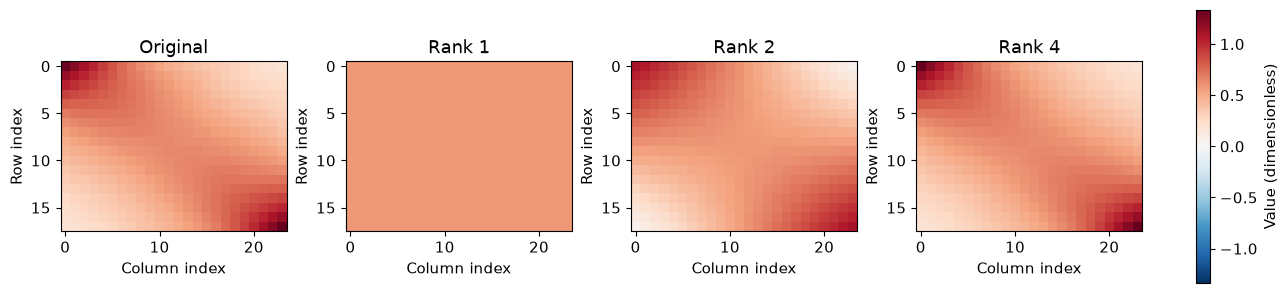

In [17]:
relative_errors = []
storage_ratios = []
norm_table = np.linalg.norm(table, "fro")
# 逐次保留前 k 个方向，同时记录重构误差和三个因子占用的标量数。
for k in range(1, 7):
    reconstructed = (u[:, :k] * s[:k]) @ vh[:k, :]
    relative_error = np.linalg.norm(table - reconstructed, "fro") / norm_table
    # 尾部奇异值给出同一 Frobenius 误差的另一条计算路径。
    tail_error = np.linalg.norm(s[k:]) / norm_table
    scalar_count = k * (sum(table.shape) + 1)
    relative_errors.append(relative_error)
    storage_ratios.append(scalar_count / table.size)
    # k=1→6 时相对误差从约 0.326 降至浮点误差量级，标量数从 43 增至 258。
    print(
        f"k={k}，相对误差={relative_error:.6g}，尾部误差={tail_error:.6g}，标量数={scalar_count}"
    )
# k=6 时数学构造已全部保留，实际误差仍可能是极小的舍入量。

# 全部热图共用原表的色标范围，避免自动缩放掩盖重构差异。
fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.5), layout="constrained")
limit = np.max(np.abs(table))
panels = [("Original", table)]
for k in [1, 2, 4]:
    panels.append((f"Rank {k}", (u[:, :k] * s[:k]) @ vh[:k, :]))
for ax, (title, values) in zip(axes, panels):
    picture = ax.imshow(
        values, cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest"
    )
    ax.set(title=title, xlabel="Column index", ylabel="Row index")
fig.colorbar(picture, ax=axes, label="Value (dimensionless)", shrink=0.8)
# 预期 rank 1 热图丢失较多细节；rank 2、rank 4 逐步靠近原图的同色位置。
plt.show()

### 6.2 同时约束误差与存储

假设这次教学任务要求相对 Frobenius 误差不超过 0.03，同时因子标量数不超过原表的一半。在候选 $k=1,\ldots,6$ 中，按从小到大的顺序选择同时满足两项条件的第一个 k。

这只是本例的明确选择规则，不是普遍推荐的阈值。更多项通常降低误差，却增加存储；如果没有候选同时满足条件，应报告条件无法同时达到，而不是忽略其中一项。

符合两项条件的 k： [3, 4, 5]
选择的最小 k： 3


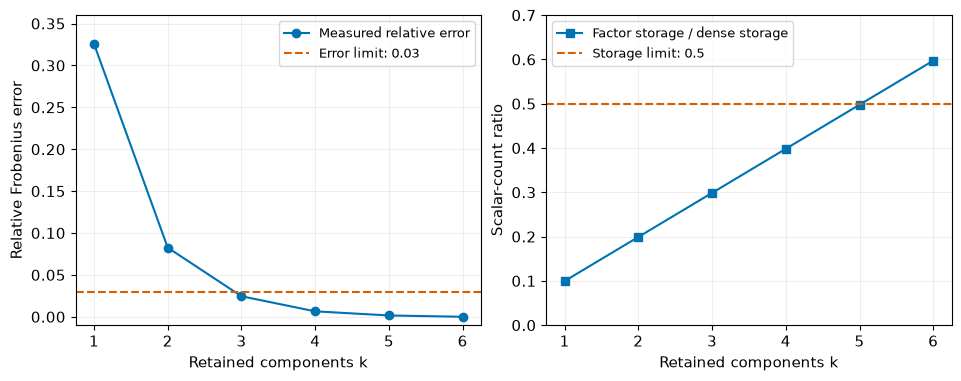

In [18]:
ks = np.arange(1, 7)
# 按 k 从小到大筛选，同时满足误差和存储比例两项要求。
eligible = [
    k
    for k, error, ratio in zip(range(1, 7), relative_errors, storage_ratios)
    if error <= 0.03 and ratio <= 0.5
]
# 本例已有满足条件的 k，按升序取第一项；改变约束后需重新判断可行性。
chosen_k = eligible[0]
print("符合两项条件的 k：", eligible)  # 预期为 [3, 4, 5]。
print("选择的最小 k：", chosen_k)  # 本例应选 3。

# 左右图分别画出约束指标；水平虚线就是筛选时使用的上限。
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7), layout="constrained")
axes[0].plot(
    ks, relative_errors, "o-", color="#0072B2", label="Measured relative error"
)
axes[0].axhline(0.03, color="#D55E00", linestyle="--", label="Error limit: 0.03")
axes[0].set(
    xlabel="Retained components k",
    ylabel="Relative Frobenius error",
    xticks=ks,
    ylim=(-0.01, 0.36),
)
axes[1].plot(
    ks, storage_ratios, "s-", color="#0072B2", label="Factor storage / dense storage"
)
axes[1].axhline(0.5, color="#D55E00", linestyle="--", label="Storage limit: 0.5")
axes[1].set(
    xlabel="Retained components k",
    ylabel="Scalar-count ratio",
    xticks=ks,
    ylim=(0, 0.7),
)
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
# 预期误差曲线下降、存储比例上升；k=3、4、5 同时低于两条约束线。
plt.show()

## 7 选学：Cholesky 利用实对称正定条件

实对称正定矩阵可以分解为 $A=LL^T$，其中 L 为下三角矩阵。这称为 Cholesky 分解。它利用的条件比 QR、SVD 更强，不能给一般矩形矩阵或半正定但不正定的矩阵直接套用同一接口。

例如设 $A=\begin{pmatrix}4&2\\2&5\end{pmatrix}$，令 $L=\begin{pmatrix}a&0\\b&c\end{pmatrix}$，选正对角元素。比较 $LL^T$ 的位置可得 $a^2=4$、$ab=2$、$b^2+c^2=5$，因此 $a=2,b=1,c=2$。

np.linalg.cholesky 默认返回下三角因子，并只读取输入的一侧三角数据，不负责检查完整矩阵的对称性。因此先确认输入对称，再核对 $LL^T$ 是否重构完整输入。

In [19]:
positive_definite = np.array([[4.0, 2.0], [2.0, 5.0]])
print("输入对称：", np.array_equal(positive_definite, positive_definite.T))  # 预期为 True。
print("特征值：", np.linalg.eigh(positive_definite).eigenvalues)  # 约为 2.43845、6.56155，都严格为正。
lower = np.linalg.cholesky(positive_definite)
print("L：\n", lower)  # [[2, 0], [1, 2]]。
print("重构误差：", np.linalg.norm(positive_definite - lower @ lower.T, "fro"))  # 预期接近 0；本次计算为 0。

semidefinite = np.diag([1.0, 0.0])

输入对称： True
特征值： [2.43844719 6.56155281]
L：
 [[2. 0.]
 [1. 2.]]
重构误差： 0.0


In [20]:
# 预期 LinAlgError：半正定矩阵不满足本例 Cholesky 的正定条件。
np.linalg.cholesky(semidefinite)

LinAlgError: Matrix is not positive definite

## 本章小结

（1）QR 把矩阵列写成正交方向上的上三角系数；矩形 Q 的列正交不等于 $QQ^T=I$。

（2）SVD 适用于任意实矩阵。完整、简化和截断是不同概念，Vh 存放的是转置后的右奇异向量。

（3）精确秩数非零奇异值，数值秩还要指定零阈值。分解因子可能有符号或基选择差异，检查应围绕重构与正交性。

（4）截断 SVD 的 Frobenius 误差由丢弃的奇异值平方和决定。节省存储还要核对因子数量，保留全部因子不一定更省。

（5）伪逆只对保留的非零奇异值取倒数。数值截断改变了被求伪逆的矩阵，Cholesky 则要求额外的对称正定条件。

自查：能否只看形状写对完整 SVD 的乘法？能否解释为什么两个正确分解的奇异向量可能不同？能否区分精确零、计算近零和主动丢弃的小奇异值？

## 练习

（1）对下面的 $3\times2$ 矩阵分别做 reduced 和 complete QR。先预测 Q、R 的形状，再检查重构误差和 $Q^TQ$。解释为什么 reduced 模式下不能要求 $QQ^T=I_3$。将第二列改为第一列的三倍后，再判断输出形状是否随秩改变。

In [21]:
exercise_qr = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
# 补充两种 QR、残差和列相关后的对照。

（2）对 $A=\operatorname{diag}(6,2,1,0.2)$，先手算保留两项时的 Frobenius 误差，再用 SVD 重构核对。若相对误差必须不超过 0.1，最小 k 是多少？按三个因子的存储口径，它是否比原始 $4\times4$ 矩阵节省标量数？说明误差合格为什么不等于压缩有效。

In [22]:
exercise_svd = np.diag([6.0, 2.0, 1.0, 0.2])
# 分别计算尾部误差、相对误差和 k * (m + n + 1)。

（3）对 $D=\operatorname{diag}(2,10^{-7},0)$，写出精确伪逆。再分别以 rcond 为 $10^{-9}$ 和 $10^{-5}$ 调用 pinv，比较 $DD^+D-D$。指出每个被置零的方向是精确零还是数值截断，不能只写“结果接近”。

In [23]:
exercise_pinv = np.diag([2.0, 1e-7, 0.0])
# 补充精确公式、两个数值结果与残差；不要对整个奇异值数组无条件取倒数。

（4）把综合例中的误差上限改为 0.001，存储比例仍不得超过 0.5。先预测原来选择的 k 是否仍可用，再重新检查全部候选；如无解，说明需要放宽哪一项条件。不要只挑误差最小的一项而遗漏存储约束。

In [24]:
new_error_limit = 0.001
storage_limit = 0.5
# 使用综合例已算出的 relative_errors 和 storage_ratios 重新筛选。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：Frobenius 误差的平方等于被舍弃奇异值的平方和。

提示 2：相对误差要除以原矩阵的 Frobenius 范数；存储量则按题目指定的三个因子另算。

### 练习（2）参考解析

原矩阵的 Frobenius 范数是 $\sqrt{41.04}$。保留两项时，误差为 $\sqrt{1^2+0.2^2}=\sqrt{1.04}$，相对误差约 0.1592，超过 0.1。保留三项时，误差为 0.2，相对误差约 0.0312；更少项的误差不会更小，因此最小 $k=3$。

按题目口径，三个因子保存 $k(m+n+1)=3(4+4+1)=27$ 个标量，原矩阵只需 16 个，因而没有节省存储。这是针对普通稠密因子的计数；本例的对角结构若另作专门存储，比较口径也要相应改变。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| TU Delft：Linear algebra | [§7.3 The Gram–Schmidt process](https://interactivetextbooks.tudelft.nl/linear-algebra/Chapter7/GramSchmidt.html)，§7.3.1–7.3.3 的逐列投影、QR 定理和矩形 Q 的边界；[§8.3 Singular value decomposition](https://interactivetextbooks.tudelft.nl/linear-algebra/Chapter8/SingularValueDecomp.html)，Definition 8.3.1、Propositions 8.3.1–8.3.2 的分解、秩与平方关系，Remark 8.3.1 的对称矩阵情形。 |
| Nick Higham 作者网站 | [What Is the Singular Value Decomposition?](https://nhigham.com/2020/10/13/what-is-the-singular-value-decomposition/)，2020-10-13：开头的形状、非唯一性和秩一展开；Eckart–Young 定理及 Frobenius 尾部误差公式；Connections with Other Problems 的伪逆表达式。 |
| Deep Learning 作者网站 | [第 2 章 Linear Algebra](https://www.deeplearningbook.org/contents/linear_algebra.html)，§2.8–2.9，印刷页 42–44：SVD 与 Moore–Penrose 伪逆，式 (2.43)、(2.47) 的矩阵形状及非零奇异值倒数。 |
| NumPy 官方文档 | NumPy 2.5：[linalg.qr](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html) 的 mode 和形状；[linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) 的完整与简化输出、Vh、递减奇异值和重构；[linalg.matrix_rank](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html) 的阈值与 Notes 中的数值秩边界；[linalg.pinv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html) 的 rcond 截断条件；[linalg.cholesky](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cholesky.html) 的正定、三角读取与异常；[linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) 的 Frobenius 范数。 |
| SciPy 官方文档 | [linalg.pinv](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinv.html)，Notes 与 Examples：伪逆的唯一性、适用矩阵形状、四个 Moore–Penrose 条件；本章使用 NumPy 执行，引用此页核对定义。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html)，二维数组、像素索引、插值和统一 vmin/vmax 色标。 |